In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# 假设你的数据是一个Series
df_good = pd.read_pickle(r'/Users/sachuriga/Desktop/Projects/CR_CA1_paper/tables/functional_properties_with_python_measurements_with_stability.pkl')
df_py = df_good[df_good['buzaki_py_cell_type']=='pyramidal']
df = df_py
base_folder = r"/Users/sachuriga/Desktop/Projects/CR_CA1_paper/Results/Functional_cell_type"
control_ids = ['65165', '65091', '63383', '66539', '65622']
exp_ids = ['65588', '63385', '66538', '66537', '66922']
sessions = ["A"]


for session in sessions:
    # Filter for sessions
    if session == "Total":
        df_a = df
    else:
        df_a = df[df['session'] == session]

    # Separate into control and experimental groups
    control_df = df_a[df_a['animal_id'].isin(control_ids)]
    exp_df = df_a[df_a['animal_id'].isin(exp_ids)]


df_con_deep = control_df[control_df['sub_population']=="deep"].reset_index(drop=True)['Information_content_rate']
df_con_superficial = control_df[control_df['sub_population']=="superficial"].reset_index(drop=True)['Information_content_rate']
df_exp_deep = exp_df[exp_df['sub_population']=="deep"].reset_index(drop=True)['Information_content_rate']
df_exp_superficial = exp_df[exp_df['sub_population']=="superficial"].reset_index(drop=True)['Information_content_rate']

def group_indices_by_step(df_col, step=0.075):
    used_indices = set()
    result = []
    values = df_col.copy()
    max_val = values.max()

    while len(used_indices) < len(values):
        remaining = values[~values.index.isin(used_indices)]
        if remaining.empty:
            break

        current_group = []
        current_val = remaining.min()
        current_idx = remaining.idxmin()
        current_group.append(current_idx)
        used_indices.add(current_idx)

        while True:
            target_val = current_val + step
            remaining = values[~values.index.isin(used_indices)]
            if remaining.empty:
                break

            # 找到大于等于 target_val 的值中最接近 target_val 的那个
            diffs = remaining - target_val
            diffs = diffs[diffs >= 0]
            if diffs.empty:
                break

            next_idx = diffs.idxmin()
            current_val = values[next_idx]
            current_group.append(next_idx)
            used_indices.add(next_idx)

        result.append(current_group)

    return result
results_con_deep = group_indices_by_step(df_con_deep)
results_con_superficial = group_indices_by_step(df_con_superficial)
results_exp_deep = group_indices_by_step(df_exp_deep)
results_exp_superficial = group_indices_by_step(df_exp_superficial)

def plot_rate_map_panel(ax, results_con, df, sublayer="deep", group = "control", map_color='jet'):
    i_row = 0
    base_y = 0.35
    y_step = 0.5

    for indices in results_con:
        y_coord = base_y + (i_row * y_step)

        if len(indices) > 0:
            values = [df[i] for i in indices]
            num_ratemaps = len(indices)
            for i, (idx, value) in enumerate(zip(indices, values)):
                img_path = fr"/Users/sachuriga/Desktop/Projects/CR_CA1_paper/Results/rate map histogram\{group}/{sublayer}/{map_color}/{idx}.png"
                plot_image_at_xy(ax, img_path, value, y_coord, max_size=0.014)
        i_row += 1
    ax.set_xlim(0, 4.5)
    ax.set_ylim(0, 3.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=10.5)
    ax.set_xlabel("Information Content Rate (spikes / bit)", fontsize=10.5)
    ax.set_yticks([])
    ax.vlines(x=[1, 2, 3, 4], ymin=0, ymax=8.5, colors='grey', linestyles='dashed', linewidth=3)
    
# Function to load and plot an image with dynamic size adjustment
def plot_image_at_xy(ax, img_path, x, y, max_size=0.09):
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        img_height, img_width = img.shape[:2]
        aspect_ratio = img_width / img_height

        # Calculate zoom based on max_size and aspect ratio
        trans = ax.transData
        fig = ax.get_figure()
        dpi = fig.dpi
        xlim = ax.get_xlim()
        data_width = xlim[1] - xlim[0]
        bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        axes_width_pixels = bbox.width * dpi
        pixels_per_data = axes_width_pixels / data_width
        size_pixels = max_size * pixels_per_data
        # zoom = size_pixels / max(img_width, img_height / aspect_ratio)

        # imagebox = OffsetImage(img, zoom=zoom)
        # ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0)
        # ax.add_artist(ab)


        zoom = 0.017  # Adjust this value to control ratemap size
        imagebox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0)
        ax.add_artist(ab)
        return ab
    else:
        print(f"Image {img_path} not found")
        return None

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, shapiro, ttest_ind, mannwhitneyu
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# Data loading
folder_path = r"/Users/sachuriga/Desktop/Projects/CR_CA1_paper/file_with_table/ripple_ch"

def get_pkl_files(folder_path):
    all_files = os.listdir(folder_path)
    pkl_files = [f for f in all_files if f.endswith("withDLC.pkl")]
    return pkl_files

target_prefixes_control = ['65165', '65091', '63383', '66539', '65622']
target_prefixes_exp = ['65588', '63385', '66538', '66537', '66922']
pkl_files = get_pkl_files(folder_path)

# # Variables to analyze
# variables = ['Information_content_rate', 'Sparsity', 'Field_size', 'Averate_rate', 'bursting_index', 'Selectivity']
# titles = ['Information content rate\n (spikes/bit)', 'Sparsity', 'Max Field Size', 'Firing Rate (Hz)', 'Bursting iondex', 'Selectivity']


variables = ['amplitude_median','half_width','peak_to_valley','peak_trough_ratio', 'recovery_slope', 'repolarization_slope']
titles = ['Amplitude median (mV)', 'Half width (ms)', 'Peak to valley (ms)', 
            'peak trough ratio', 'Recovery slope', 'repolarization_slope']
        
all_dfs = []
scale_transefers = [0.001,1000,1000,1,0.00001,0.000001]

# Process each pickle file
for file in pkl_files:
    try:
        df = pd.read_pickle(os.path.join(folder_path, file))
    except Exception as e:
        continue
    #df = df[(df['cell_type'] == "pyramidal") & (df['session'] == "A")]
    df = df[(df['buzaki_py_cell_type'] == "pyramidal") & (df['session'] == "A")  & (df['unit_quality'] == "good")]
    #df = df[df['session'] == "A"]
    if df.empty:
        print(f"Warning: File {file} has no pyramidal cells")
        continue
    try:
        animal_id = df['animal_id'].iloc[0]
    except KeyError:
        print(f"Warning: File {file} does not have 'animal_id' column")
        continue
    if any(animal_id.startswith(prefix) for prefix in target_prefixes_control):
        df['group_ani'] = 'control'
    elif any(animal_id.startswith(prefix) for prefix in target_prefixes_exp):
        df['group_ani'] = 'exp'
    else:
        print(f"Warning: animal_id {animal_id} does not match any group")
        continue
    all_dfs.append(df)

y_pos = "addjust y r2"
combined_df=[]
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df['depth'] = combined_df[y_pos].apply(lambda x: 'deep' if x > 0 else 'superficial')
combined_df['group_depth'] = combined_df['group_ani'] + '_' + combined_df['depth']

# Convert variables to numeric and handle invalid values
for var in variables:
    combined_df[var] = pd.to_numeric(combined_df[var], errors='coerce')
    if combined_df[var].isna().any():
        print(f"Warning: {var} contains NaN values after conversion to numeric")

# Function to test normality and choose test
def choose_stat_test(data1, data2, var_name, group1_name, group2_name):
    # Drop NaN values and ensure numeric
    data1 = data1.dropna()
    data2 = data2.dropna()
    
    # Check for non-numeric values
    if not np.issubdtype(data1.dtype, np.number) or not np.issubdtype(data2.dtype, np.number):
        print(f"Error: Non-numeric data detected in {var_name} for {group1_name} or {group2_name}")
        print(f"{group1_name} dtype: {data1.dtype}, {group2_name} dtype: {data2.dtype}")
        print(f"{group1_name} sample: {data1.head()}")
        print(f"{group2_name} sample: {data2.head()}")
        return "Invalid", np.nan, np.nan

    # Check if data is empty after dropping NaNs
    if len(data1) == 0 or len(data2) == 0:
        print(f"Error: Empty dataset for {var_name} in {group1_name} or {group2_name} after dropping NaNs")
        return "Empty", np.nan, np.nan

    # Perform Shapiro-Wilk test for normality
    stat1, p1 = shapiro(data1)
    stat2, p2 = shapiro(data2)
    
    print(f"{var_name} - {group1_name} Shapiro-Wilk: p={p1:.4f}")
    print(f"{var_name} - {group2_name} Shapiro-Wilk: p={p2:.4f}")
    
    # Choose test based on normality
    if p1 > 0.05 and p2 > 0.05:  # Both are normal
        print(f"{var_name} - Using t-test (both groups normal)")
        stat, p = ttest_ind(data1, data2, equal_var=True)  # Assuming equal variances
        test_name = "t-test"
    else:
        print(f"{var_name} - Using Mann-Whitney U test (non-normal distribution)")
        stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney U"
    
    return test_name, stat, p

group_ani = []
control_ids = ['65165', '65091', '63383', '66539', '65622']
exp_ids = ['65588', '63385', '66538', '66537', '66922']
for index, row in combined_df.iterrows():
    if str(row['matlab_animal']) in control_ids:
        group_ani.append("control")
    else:
        group_ani.append("exp")
combined_df['group_ani']=None
combined_df['group_ani']=group_ani

from scipy.stats import binomtest
control_df_deep = combined_df[(combined_df['group_ani'] == 'control')]
exp_df_deep = combined_df[(combined_df['group_ani'] == 'exp')]

# # Control_superficial vs. Exp_superficial
# control_superficial = combined_df[(combined_df['group_ani'] == 'control') & (combined_df['depth'] == 'superficial')][var]
# exp_superficial = combined_df[(combined_df['group_ani'] == 'exp') & (combined_df['depth'] == 'superficial')][var]

control_df_place = control_df_deep[(control_df_deep['h_0_place_cell'] == 1) & 
                                (control_df_deep['Information_content_rate'] >= 1.71) & 
                                (control_df_deep['matlab_maxfsize'] >= 20) ]
exp_df_place = exp_df_deep[(exp_df_deep['h_0_place_cell'] == 1) & 
                        (exp_df_deep['Information_content_rate'] >= 1.71) & 
                        (exp_df_deep['matlab_maxfsize'] >= 20) ]

combined_df = pd.concat([control_df_place, exp_df_place], ignore_index=True)


n numbers con deep 50 n number exp deep 47
Error: Non-numeric data detected in Information content rate
 (spikes/bit) for Control_deep or Exp_deep
Control_deep dtype: object, Exp_deep dtype: object
Control_deep sample: 0    1.907444
1    2.092892
2    1.942617
3     1.87963
4    2.781622
Name: Information_content_rate, dtype: object
Exp_deep sample: 87    2.055044
88    1.850682
89    1.722137
90    2.000959
91    2.362285
Name: Information_content_rate, dtype: object
Information content rate
 (spikes/bit) - Control_deep vs. Exp_deep (Invalid): statistic=nan, p-value=nan
Error: Non-numeric data detected in Information content rate
 (spikes/bit) for Control_superficial or Exp_superficial
Control_superficial dtype: object, Exp_superficial dtype: object
Control_superficial sample: 5     2.239492
11    2.117449
13    2.044906
14     2.42181
15    2.868464
Name: Information_content_rate, dtype: object
Exp_superficial sample: 98     1.751981
99     1.812088
112    1.862147
116    2.988307
11

/var/folders/4n/7433hdp506j3m_tyq8t12fgc0000gn/T/ipykernel_75065/2258761617.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis[i].legend().set_visible(False)
/var/folders/4n/7433hdp506j3m_tyq8t12fgc0000gn/T/ipykernel_75065/2258761617.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['CR;DTA-', 'CR;DTA+'], rotation = -45)
/var/folders/4n/7433hdp506j3m_tyq8t12fgc0000gn/T/ipykernel_75065/2258761617.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis[i].legend().set_visible(False)
/var/folders/4n/7433hdp506j3m_tyq8t12fgc0000gn/T/ipykernel_75065/2258761617.py:94: UserWarning: set_ticklabels() should only be used with a fixed 

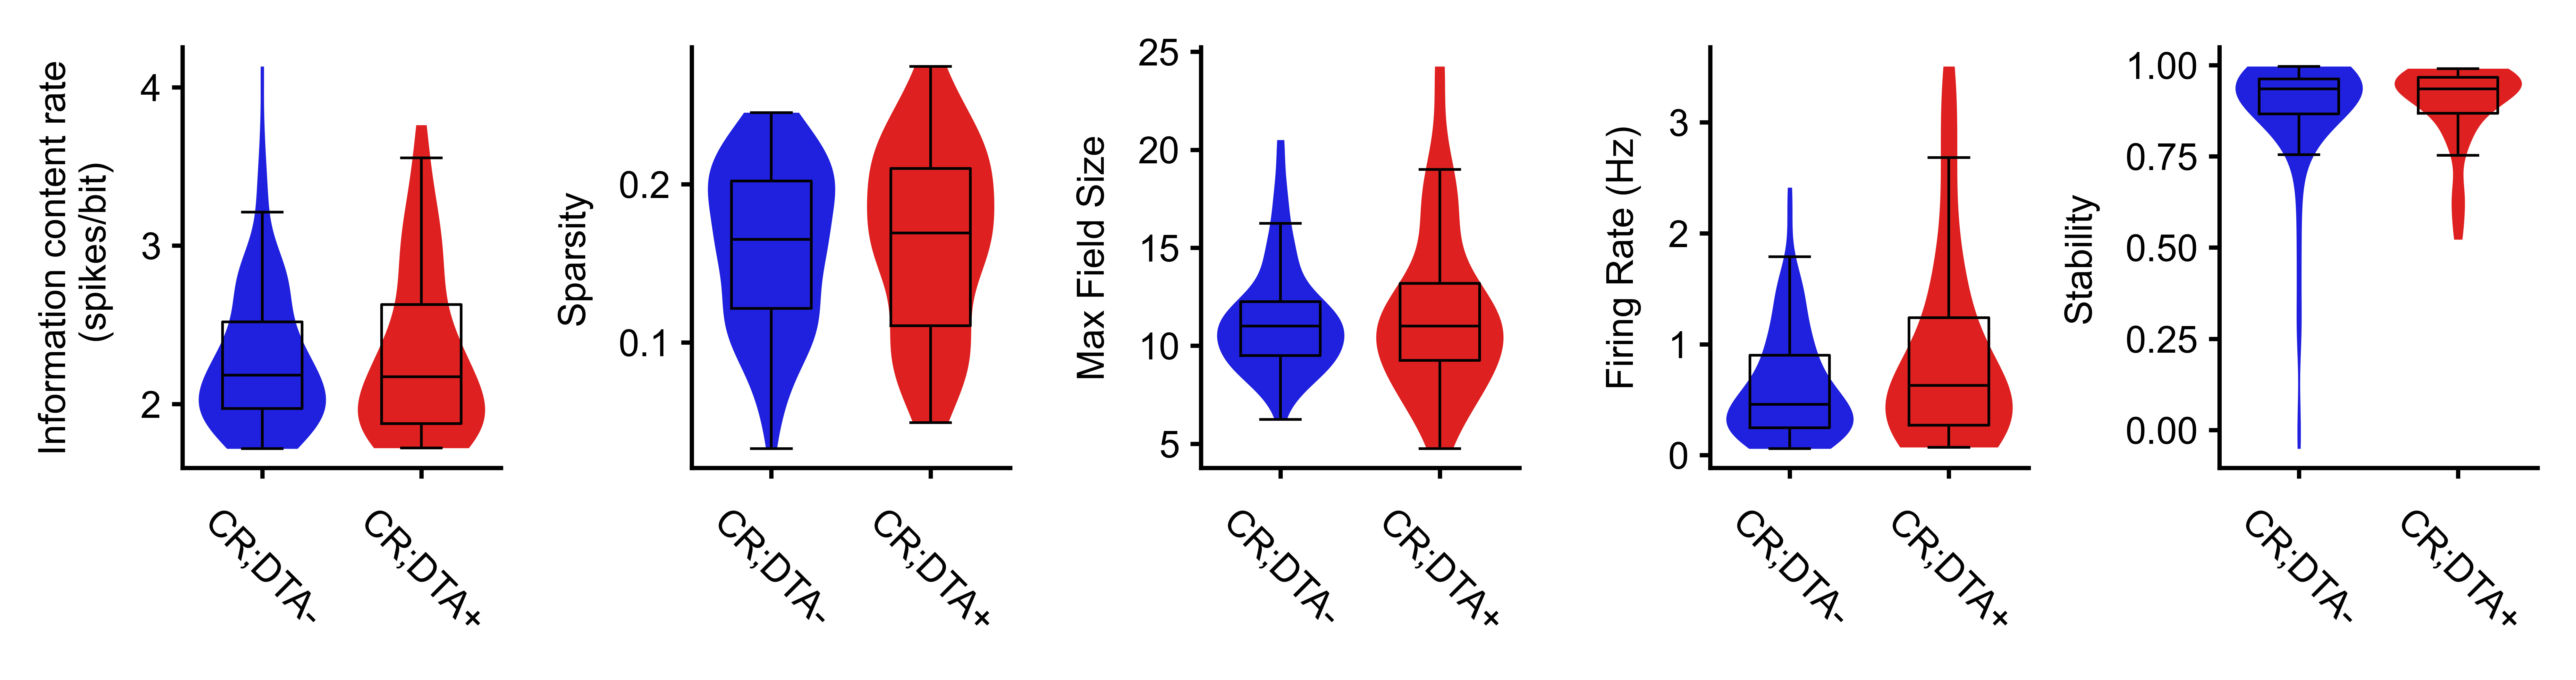

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection

fig = plt.figure(figsize=(7.2, 1.3), dpi=1200)
plt.rcParams.update({'font.size': 7,'font.family': 'sans-serif','font.sans-serif':['Calibri', 'Arial', 'DejaVu Sans', 'sans-serif']})
plt.rcParams.update({
    'axes.labelpad': 5,
    'ytick.major.pad': 2,
    'xtick.major.pad': 5,
    'ytick.major.size': 2,
    'xtick.major.size': 2
})

gs = gridspec.GridSpec(1, 5, height_ratios=[1], width_ratios=[1,1,1,1,1])  # First row taller

linewidth = 0.5
variables = ['Information_content_rate', 'Sparsity', 'Field_size', 'Averate_rate', 'stability_ma']
titles = ['Information content rate\n (spikes/bit)', 'Sparsity', 'Max Field Size', 'Firing Rate (Hz)', 'Stability']

import numpy as np
import matplotlib.pyplot as plt

## funtional properties
ax4_1 = fig.add_subplot(gs[0, 0])
ax4_2 = fig.add_subplot(gs[0, 1])
ax4_3 = fig.add_subplot(gs[0, 2])
ax4_4 = fig.add_subplot(gs[0, 3])
ax4_5 = fig.add_subplot(gs[0, 4])

axis = [ax4_1,ax4_2,ax4_3,ax4_4,ax4_5]

palette = {'control': 'blue', 'exp': 'red'}
#combined_df=pd.read_pickle(r"Q:\sachuriga\CR_CA1_paper\tables/functional_properties_with_python_measurements.pkl")
for i, (var, title) in enumerate(zip(variables, titles)):
    # Control_deep vs. Exp_deep
    control_deep = combined_df[(combined_df['group_ani'] == 'control') & (combined_df['sub_population'] == 'deep')][var]
    exp_deep = combined_df[(combined_df['group_ani'] == 'exp') & (combined_df['sub_population'] == 'deep')][var]
    n_deep=len(control_deep)
    en_deep=len(exp_deep)
    print(fr"n numbers con deep {n_deep} n number exp deep {en_deep}")
    # Choose test for deep
    test_name_deep, stat_deep, p_valued = choose_stat_test(control_deep, exp_deep, title, "Control_deep", "Exp_deep")
    print(f"{title} - Control_deep vs. Exp_deep ({test_name_deep}): statistic={stat_deep:.3f}, p-value={p_valued:.4f}")
    
    # Control_superficial vs. Exp_superficial
    control_superficial = combined_df[(combined_df['group_ani'] == 'control') & (combined_df['sub_population'] == 'superficial')][var]
    exp_superficial = combined_df[(combined_df['group_ani'] == 'exp') & (combined_df['sub_population'] == 'superficial')][var]
    
    # Choose test for superficial
    test_name_sup, stat_sup, p_values = choose_stat_test(control_superficial, exp_superficial, title, "Control_superficial", "Exp_superficial")
    print(f"{title} - Control_superficial vs. Exp_superficial ({test_name_sup}): statistic={stat_sup:.3f}, p-value={p_values:.4f}")
    ks_stat_deep, p_value_d = ks_2samp(control_deep, exp_deep, nan_policy='omit')
    ks_stat_sup, p_values_s = ks_2samp(control_superficial, exp_superficial, nan_policy='omit')

    
    sns.violinplot(
        data=combined_df, 
        x='group_ani', 
        y=var, 
        ax=axis[i], 
        hue='group_ani', 
        inner=None,
        palette={"control": "blue", "exp": "red"},
        cut=0, 
        linewidth=0  # Removes the outline
    )

    # Boxplot: only edge lines with midline (median), hide outliers, no fill, no mean marker
    # Adjusted to make the boxplot lines narrower (thinner) by setting linewidth=1 (adjust as needed, e.g., 0.5 for even thinner)
    sns.boxplot(
        data=combined_df, 
        x='group_ani', 
        y=var, 
        ax=axis[i], 
        hue='group_ani', 
        palette={"control": "black", "exp": "black"},
        width=0.5, 
        fill=False,  # No fill, only outlines
        showfliers=False,  # Hide outliers
        showmeans=False,  # Remove mean marker, assuming midline is the median
        linewidth=0.5,  # Makes the lines narrower (thinner)
        boxprops={"zorder": 3}
    )
    for l in axis[i].get_children():
        if isinstance(l, LineCollection):  # Quartile lines are LineCollections
            l.set_linewidth(0.5)
    axis[i].set_xlabel(title).set_visible(False)
    axis[i].set_ylabel(f'{title}')
    axis[i].legend().set_visible(False)
    axis[i].spines['top'].set_visible(False)
    axis[i].spines['right'].set_visible(False)
    ax=axis[i]
    ax.set_xticklabels(['CR;DTA-', 'CR;DTA+'], rotation = -45)
    y_max = ax.get_ylim()[1]
    bar_height = y_max * 0.1  # Adjust this value to position the bar above the plot
    x_positions = [0, 1]  # Adjusted positions for 'Control' and 'Experimental' groups
    p_val = p_valued
    if (p_val < 0.05) & (p_val > 0.01):
        ax.plot([x_positions[0], x_positions[1]], [y_max + bar_height, y_max + bar_height], 
                            color='black', lw=1.5)
        ax.text(0.5, y_max + bar_height * 1.1, f'*', ha='center', va='bottom')
    elif (p_val < 0.01) & (p_val > 0.001):
        ax.plot([x_positions[0], x_positions[1]], [y_max + bar_height, y_max + bar_height], 
                            color='black', lw=1.5)
        ax.text(0.5, y_max + bar_height * 1.1, f'**', ha='center', va='bottom')
    elif p_val < 0.001:
        ax.plot([x_positions[0], x_positions[1]], [y_max + bar_height, y_max + bar_height], 
                            color='black', lw=1.5)
        ax.text(0.5, y_max + bar_height * 1.1, f'***', ha='center', va='bottom')


#plt.rcParams.update({'font.size': 7})
plt.tight_layout()
fig.subplots_adjust(top=0.92, bottom=0.08, left=0.1, right=0.95, hspace=0.1, wspace=0.6)
plt.savefig(r'/Users/sachuriga/Desktop/Projects/CR_CA1_paper/Figures_mac/supfig11.png', transparent=True, dpi=1200, bbox_inches='tight')
plt.show()